In [5]:
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
adata = sc.read_h5ad("/project/imoskowitz/yubin/1-sc_practice/SmoNull_Brain_system_normalized.h5ad")

In [7]:
adata

AnnData object with n_obs × n_vars = 38311 × 33696
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Condition', 'Library.ident', 'Sample', 'Replicate', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.1', 'seurat_clusters', 'doublet_finder', 'doublet_status', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'SCT_snn_res.1', 'SCT_snn_res.4', 'Extended_mouse_gastrulation_label', 'System', 'ClusterSystem', 'total_counts', 'size_factors'
    var: 'features'
    uns: 'ClusterSystem_colors', 'log1p'
    obsm: 'X_umap'
    layers: 'analytic_pearson_residuals', 'log1p_norm', 'norm_counts', 'raw_counts', 'scran_normalization'

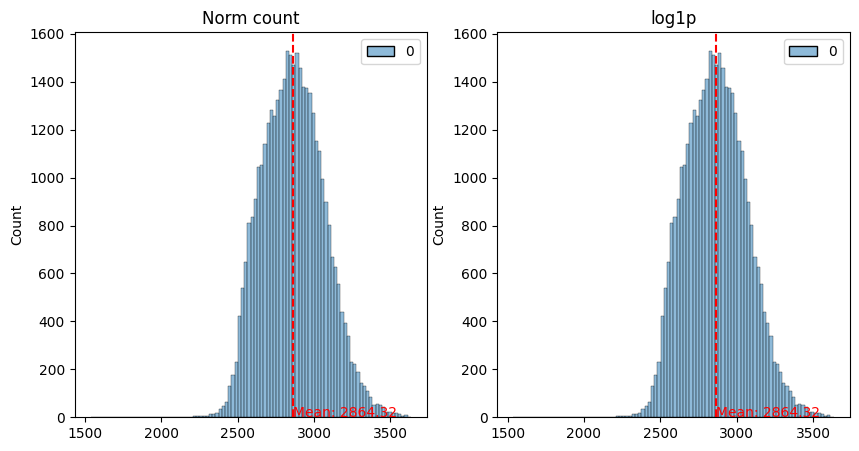

In [9]:
# Comparing what the difference between norm_counts and log1p_norm is, the first is imported along with the data in normalized, the latter is created in normalized
# Apprarently they are exactly the same

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(adata.layers["norm_counts"].sum(1), bins=100, kde=False, ax=axes[0])
axes[0].set_title("Norm count")
mean_norm = adata.layers["norm_counts"].sum(1).mean()
axes[0].text(mean_norm, 0.5, f'Mean: {mean_norm:.2f}', color='red')
axes[0].axvline(mean_norm, color='red', linestyle='--')

p2 = sns.histplot(adata.layers["log1p_norm"].sum(1), bins=100, kde=False, ax=axes[1])
mean_log1p = adata.layers["log1p_norm"].sum(1).mean()
axes[1].text(mean_log1p, 0.5, f'Mean: {mean_log1p:.2f}', color='red')
axes[1].axvline(mean_log1p, color='red', linestyle='--')
axes[1].set_title("log1p")
plt.show()

In [10]:
del adata.layers["norm_counts"]

In [11]:
adata

AnnData object with n_obs × n_vars = 38311 × 33696
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Condition', 'Library.ident', 'Sample', 'Replicate', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.1', 'seurat_clusters', 'doublet_finder', 'doublet_status', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'SCT_snn_res.1', 'SCT_snn_res.4', 'Extended_mouse_gastrulation_label', 'System', 'ClusterSystem', 'total_counts', 'size_factors'
    var: 'features'
    uns: 'ClusterSystem_colors', 'log1p'
    obsm: 'X_umap'
    layers: 'analytic_pearson_residuals', 'log1p_norm', 'raw_counts', 'scran_normalization'

# First let us create a umap of the current normalize dataset to create a base reference for how the batch effect is changing the layout

## log1_p count UMAP generation

In [12]:
adata.X = adata.layers["log1p_norm"]

### Feature Selection

In [13]:
adata.obs["Library.ident"]


Sample1_Control_rep1_AAACCAAAGAATCAAG-1    Batch1
Sample1_Control_rep1_AAACCAAAGATTGACT-1    Batch1
Sample1_Control_rep1_AAACCATTCAGCAGGA-1    Batch1
Sample1_Control_rep1_AAACCCGCAATGCCAG-1    Batch1
Sample1_Control_rep1_AAACCCGCAGCACTTC-1    Batch1
                                            ...  
Sample6_SmoNull_rep3_TGTGGTTGTGCGGCTT-1    Batch2
Sample6_SmoNull_rep3_TGTGTACGTCAAGTCT-1    Batch2
Sample6_SmoNull_rep3_TGTGTACGTTCCGTTC-1    Batch2
Sample6_SmoNull_rep3_TGTGTTGAGCAGGTAG-1    Batch2
Sample6_SmoNull_rep3_TGTGTTGAGTAGAGGT-1    Batch2
Name: Library.ident, Length: 38311, dtype: category
Categories (2, object): ['Batch1', 'Batch2']

In [14]:
# I removed the batch_key specificity because I want to see the umap without any batch correction
# TODO: Maybe set the batch_key to true too and see what would happen, but really it wouldn't matter cause none of these steps are going to be used for integration
#sc.pp.highly_variable_genes(adata, n_top_genes=2000)

In [15]:
#sc.pl.highly_variable_genes(adata)

Same thing but with the batch specified, this will be rerun in place for the above with the downstream generation to see what sort of difference it will make

In [16]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="Library.ident") 
# note accounting for batch will exponetial expend more computational time

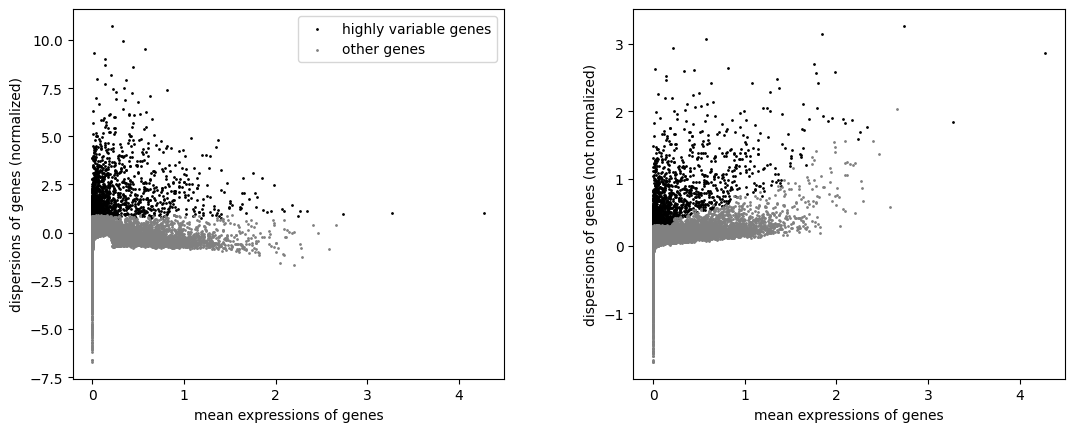

In [17]:
sc.pl.highly_variable_genes(adata)

pca analysis to find main axes of variance

In [18]:
sc.tl.pca(adata)

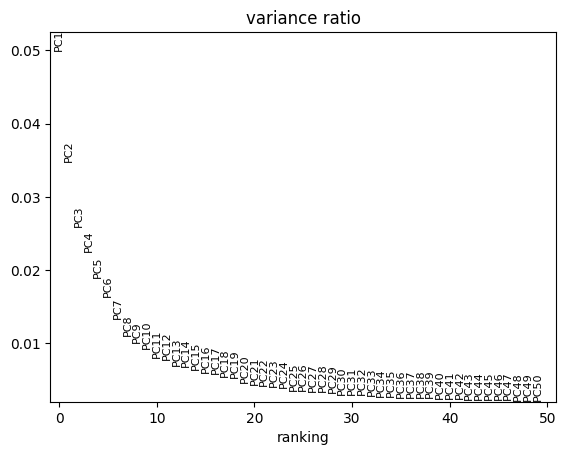

In [19]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=False)

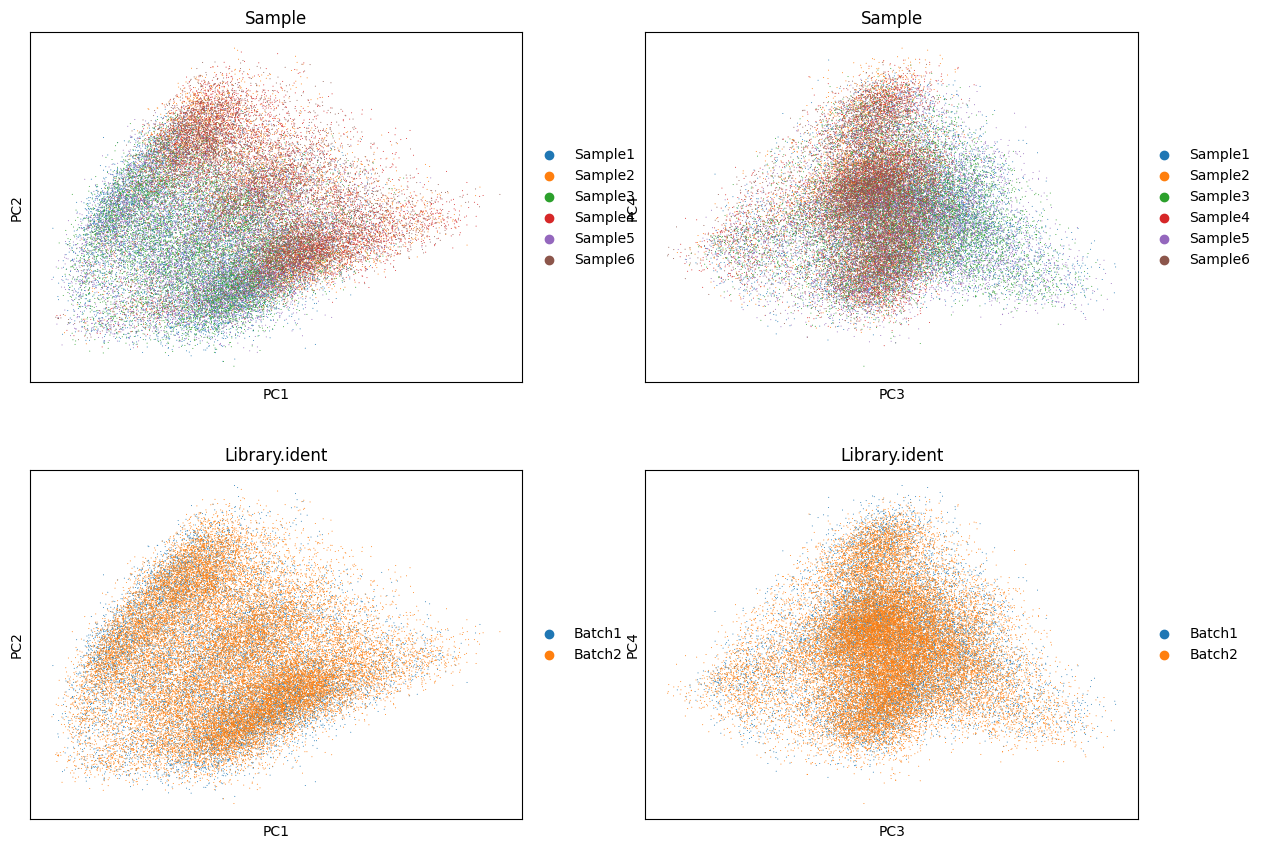

In [ ]:
sc.pl.pca(
    adata,
    color=["Sample", "Sample", "Library.ident", "Library.ident"], 
    dimensions=[(0, 1), (2, 3), (0, 1), (2, 3)], 
    ncols=2,
    size=2,
)

In [28]:
sc.pp.neighbors(adata) #TODO Add n_pc and check if there are any noticable difference between the umaps

SystemError: CPUDispatcher(<function nn_descent at 0x7f85eb618680>) returned a result with an exception set

In [22]:
sc.tl.umap(adata)

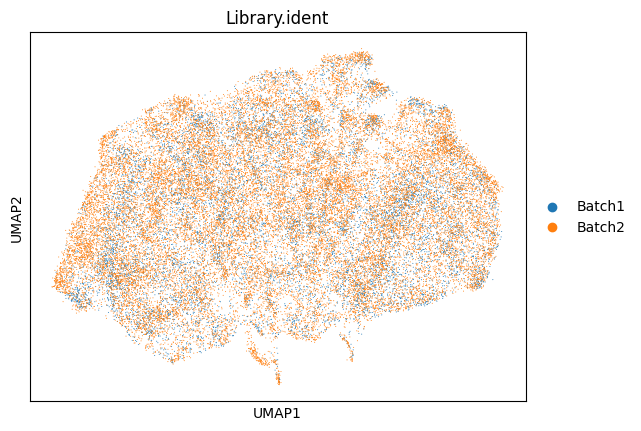

In [23]:
sc.pl.umap(
    adata,
    color="Library.ident",
    # Setting a smaller point size to get prevent overlap
    size=2,
)

## Scran Normalized Umap

In [24]:
adata

AnnData object with n_obs × n_vars = 38311 × 33696
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Condition', 'Library.ident', 'Sample', 'Replicate', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.1', 'seurat_clusters', 'doublet_finder', 'doublet_status', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'SCT_snn_res.1', 'SCT_snn_res.4', 'Extended_mouse_gastrulation_label', 'System', 'ClusterSystem', 'total_counts', 'size_factors'
    var: 'features', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'ClusterSystem_colors', 'log1p', 'hvg', 'pca', 'Sample_colors', 'Library.ident_colors', 'neighbors', 'umap'
    obsm: 'X_umap', 'X_pca'
    varm: 'PCs'
    layers: 'analytic_pearson_residuals', 'log1p_norm', 'raw_counts', 'scran_normalization'
    obsp: 'distances', 'connectivities'

In [ ]:
scran_adata = adata.layers["scran_normalization"]

In [26]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="Library.ident")

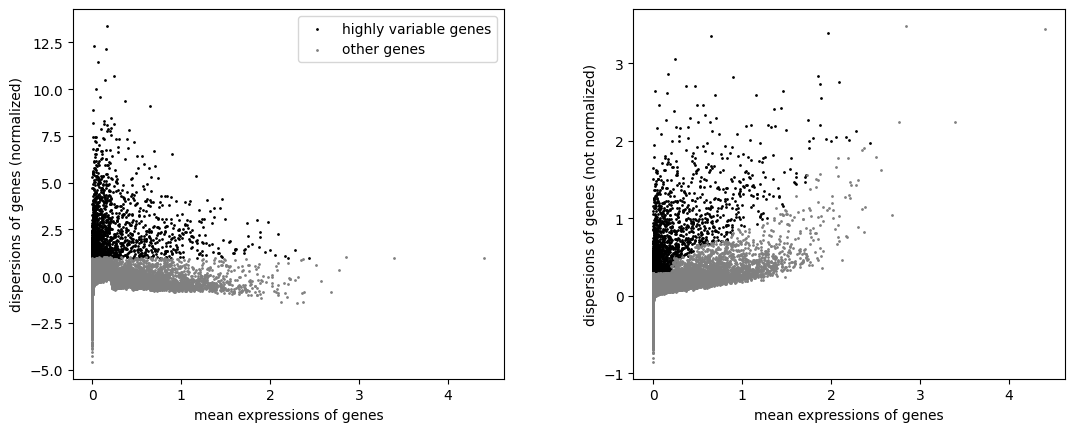

In [29]:
sc.pl.highly_variable_genes(adata)

In [ ]:
sc.pp.pca